# Generate Figures 1, 2 & 3: SHAP Analysis Visualizations

This notebook generates visualization figures for the paper.

## What This Notebook Generates:

### Figure 1: SHAP Magnitude Distributions by Prediction Type

1. **Two-panel figure**: Boxplot + Violin plot comparison
   - Saved as: `outputs/figure1_shap_magnitude_distributions.png`

2. **Single-panel figure** (recommended for paper): Boxplot only
   - Saved as: `outputs/figure1_shap_distributions_single.png`
   - **Use this version for the paper**

**Features:**
- Boxplots/violin plots of mean |SHAP| per instance
- Separate panels for: **TP, FP, TN** prediction types
- Comparison between: **bias-detector vs. DA-RoBERTa** models
- Color-coded by prediction type (TP=green, FP=red, TN=blue)

### Figure 2: Global Top Bias Indicators

- **Side-by-side horizontal bar charts**: Top 10 words by mean |SHAP|
  - Saved as: `outputs/figure2_top_bias_indicators.png`
  - One chart for bias-detector, one for DA-RoBERTa

**Features:**
- Horizontal bar charts showing top 10 bias-indicating words
- Values labeled on bars
- Color-coded by model (bias-detector=blue, DA-RoBERTa=green)

### Figure 3: Word Category Composition of Top SHAP Features

- **Stacked bar charts**: Word category proportions
  - Saved as: `outputs/figure3_word_category_composition.png`
  - Comparison between bias-detector and DA-RoBERTa

- **Optional TP/FP breakdown**: 2x2 subplot grid
  - Saved as: `outputs/figure3_tp_fp_breakdown.png`
  - Shows category composition separately for TP and FP predictions

**Features:**
- Categories: Emotional/Evaluative, Explicit Bias Terms, Framing/Reporting Verbs, Function/Temporal Words
- Proportions shown as percentages
- Color-coded categories with clear legend

## How to Use:
1. Run all cells sequentially
2. Figures are automatically saved to the `outputs/` directory
3. All figures are publication-quality (300 DPI)


In [36]:
# Imports
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("✅ Imports loaded")


✅ Imports loaded


## Load and Process Data


In [37]:
# Configuration
output_dir = "outputs"

def load_shap_data(jsonl_path):
    """Load SHAP samples from JSONL file."""
    samples = []
    with open(jsonl_path, 'r') as f:
        for line in f:
            samples.append(json.loads(line))
    return samples

def calculate_mean_abs_shap_per_instance(sample):
    """Calculate mean absolute SHAP value per instance."""
    if 'word_attribs' in sample:
        # Calculate from word attributions
        abs_shaps = [abs(word_attr['shap']) for word_attr in sample['word_attribs']]
        return np.mean(abs_shaps) if abs_shaps else 0.0
    elif 'shap_pos' in sample:
        # Calculate from token-level SHAP values
        abs_shaps = [abs(val) for val in sample['shap_pos'] if isinstance(val, (int, float))]
        return np.mean(abs_shaps) if abs_shaps else 0.0
    return 0.0

def determine_pred_type(gold, pred):
    """Determine prediction type: TP, FP, TN, FN."""
    if gold == 1 and pred == 1:
        return 'TP'
    elif gold == 0 and pred == 1:
        return 'FP'
    elif gold == 0 and pred == 0:
        return 'TN'
    else:  # gold == 1 and pred == 0
        return 'FN'

print("✅ Helper functions defined")


✅ Helper functions defined


In [38]:
# Load data for both models
print("Loading SHAP data for both models...")

# Original model (bias-detector)
original_path = os.path.join(output_dir, "shap_samples.jsonl")
if not os.path.exists(original_path):
    # Try alternative paths
    alt_paths = [
        os.path.join(output_dir, "shap_samples237.jsonl"),
    ]
    for alt_path in alt_paths:
        if os.path.exists(alt_path):
            original_path = alt_path
            break

original_samples = load_shap_data(original_path)
print(f"✅ Loaded {len(original_samples)} samples from original model")

# DA-RoBERTa model
daroberta_path = os.path.join(output_dir, "shap_samples_daroberta.jsonl")
daroberta_samples = load_shap_data(daroberta_path)
print(f"✅ Loaded {len(daroberta_samples)} samples from DA-RoBERTa model")


Loading SHAP data for both models...
✅ Loaded 237 samples from original model
✅ Loaded 212 samples from DA-RoBERTa model


In [45]:
# Process original model data
original_data = []
for sample in original_samples:
    mean_abs_shap = calculate_mean_abs_shap_per_instance(sample)
    pred_type = determine_pred_type(sample['gold'], sample['pred'])
    original_data.append({
        'model': 'bias-detector',
        'pred_type': pred_type,
        'mean_abs_shap': mean_abs_shap,
        'gold': sample['gold'],
        'pred': sample['pred'],
        'prob_pos': sample.get('prob_pos', 0.0)
    })

# Process DA-RoBERTa model data
daroberta_data = []
for sample in daroberta_samples:
    mean_abs_shap = calculate_mean_abs_shap_per_instance(sample)
    pred_type = determine_pred_type(sample['gold'], sample['pred'])
    daroberta_data.append({
        'model': 'DA-RoBERTa model',
        'pred_type': pred_type,
        'mean_abs_shap': mean_abs_shap,
        'gold': sample['gold'],
        'pred': sample['pred'],
        'prob_pos': sample.get('prob_pos', 0.0)
    })

# Combine into DataFrame
df = pd.DataFrame(original_data + daroberta_data)

# Filter to only TP, FP, TN (exclude FN)
df = df[df['pred_type'].isin(['TP', 'FP', 'TN'])]

print("✅ Data processed")
print(f"\nData summary:")
print(df.groupby(['model', 'pred_type']).size())
print(f"\nMean |SHAP| by model and type:")
print(df.groupby(['model', 'pred_type'])['mean_abs_shap'].agg(['mean', 'std', 'count']).round(4))


✅ Data processed

Data summary:
model             pred_type
DA-RoBERTa model  FP            12
                  TN           100
                  TP           100
bias-detector     FP            37
                  TN           100
                  TP           100
dtype: int64

Mean |SHAP| by model and type:
                              mean     std  count
model            pred_type                       
DA-RoBERTa model FP         0.0310  0.0150     12
                 TN         0.0146  0.0125    100
                 TP         0.0335  0.0193    100
bias-detector    FP         0.0447  0.0220     37
                 TN         0.0324  0.0199    100
                 TP         0.0362  0.0255    100


## Generate Figure 1: SHAP Magnitude Distributions


Prepared 6 data groups for plotting
Positions: [0, 1, 2, 3.5, 4.5, 5.5]
Labels: ['bias-detector\nTP', 'bias-detector\nFP', 'bias-detector\nTN', 'DA-RoBERTa model\nTP', 'DA-RoBERTa model\nFP', 'DA-RoBERTa model\nTN']


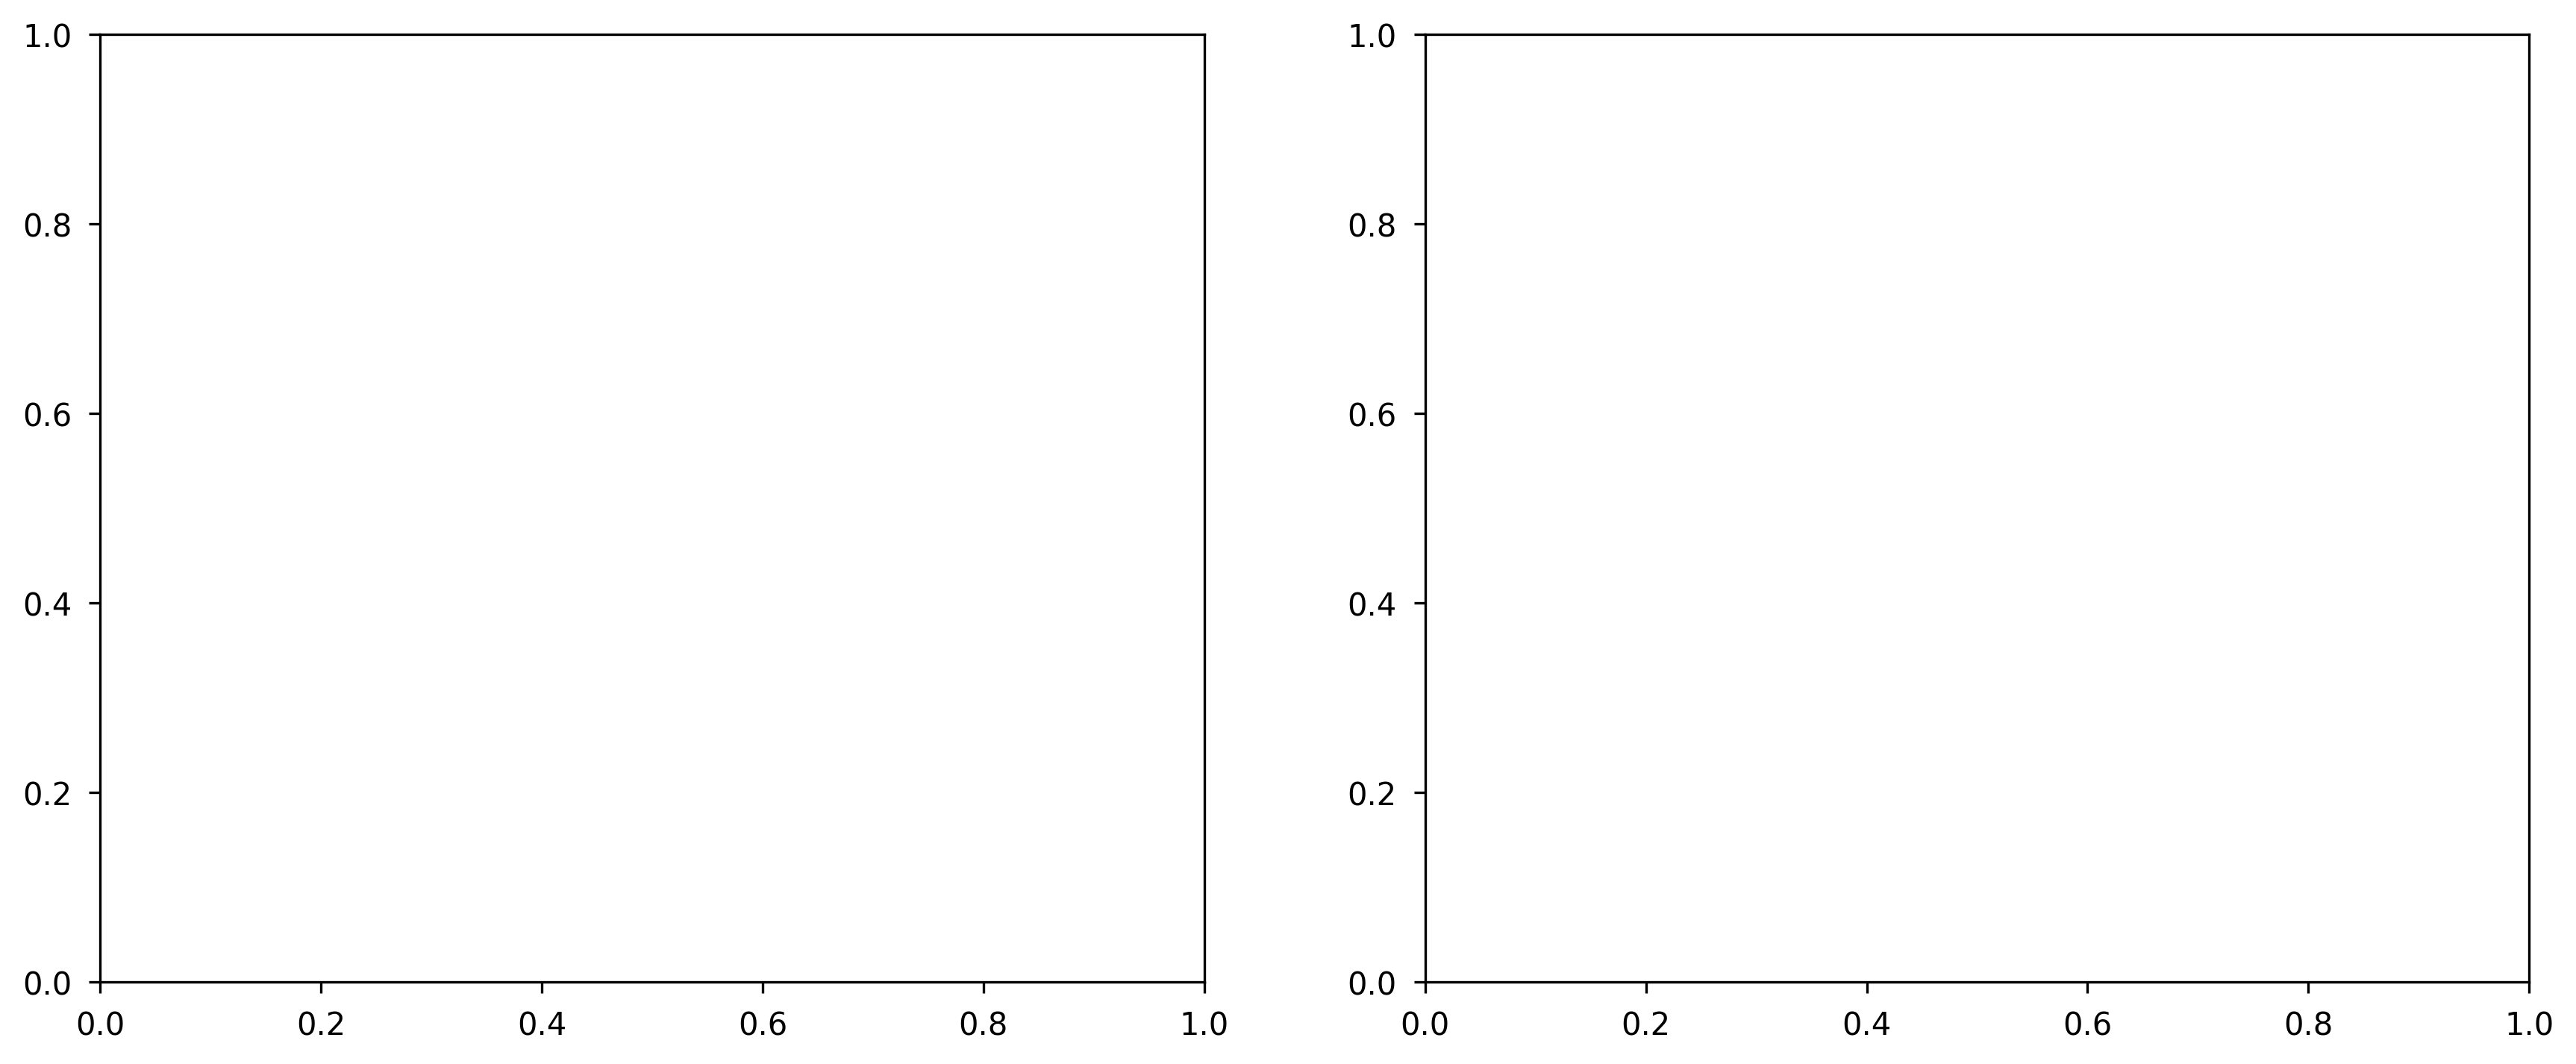

In [47]:
# Create the figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Define colors for prediction types
colors = {'TP': '#2ecc71', 'FP': '#e74c3c', 'TN': '#3498db'}  # Green, Red, Blue
type_order = ['TP', 'FP', 'TN']

# Prepare data for plotting
data_list = []
labels_list = []
positions = []
pos = 0

for model_name in ['bias-detector', 'DA-RoBERTa model']:
    for pred_type in type_order:
        data = df[(df['model'] == model_name) & (df['pred_type'] == pred_type)]['mean_abs_shap'].values
        if len(data) > 0:
            data_list.append(data)
            labels_list.append(f"{model_name}\n{pred_type}")
            positions.append(pos)
            pos += 1
    pos += 0.5  # Add space between models

# Create labels for x-axis
x_labels = []
for label in labels_list:
    parts = label.split('\n')
    if len(parts) == 2:
        x_labels.append(f"{parts[0]}\n{parts[1]}")
    else:
        x_labels.append(label)

# Calculate mid-point for separating models
mid_point = (positions[2] + positions[3]) / 2

print(f"Prepared {len(data_list)} data groups for plotting")
print(f"Positions: {positions}")
print(f"Labels: {x_labels}")


In [48]:
# Plot 1: Boxplot
ax1 = axes[0]

bp = ax1.boxplot(data_list, positions=positions, widths=0.6, patch_artist=True,
                 labels=x_labels,
                 showmeans=True, meanline=True)

# Color the boxes by prediction type
for i, patch in enumerate(bp['boxes']):
    label = labels_list[i]
    if 'TP' in label:
        patch.set_facecolor(colors['TP'])
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        patch.set_linewidth(1)
    elif 'FP' in label:
        patch.set_facecolor(colors['FP'])
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        patch.set_linewidth(1)
    elif 'TN' in label:
        patch.set_facecolor(colors['TN'])
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

ax1.set_ylabel('Mean |SHAP| per Instance', fontsize=12, fontweight='bold')
ax1.set_xlabel('Model × Prediction Type', fontsize=12, fontweight='bold')
ax1.set_title('(a) Boxplot: SHAP Magnitude Distributions', fontsize=13, fontweight='bold', pad=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0, max(df['mean_abs_shap']) * 1.2])

# Add vertical line to separate models
ax1.axvline(x=mid_point, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)

print("✅ Boxplot created")


✅ Boxplot created


In [49]:
# Plot 2: Violin plot (alternative view)
ax2 = axes[1]

# Prepare data for violin plot using the same structure
violin_parts = ax2.violinplot(data_list, positions=positions, widths=0.6, 
                              showmeans=True, showmedians=True)

# Color the violins
for i, pc in enumerate(violin_parts['bodies']):
    label_idx = i % 3
    pred_type = type_order[label_idx]
    pc.set_facecolor(colors[pred_type])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

ax2.set_ylabel('Mean |SHAP| per Instance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Model × Prediction Type', fontsize=12, fontweight='bold')
ax2.set_title('(b) Violin Plot: SHAP Magnitude Distributions', fontsize=13, fontweight='bold', pad=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim([0, max(df['mean_abs_shap']) * 1.2])

# Set x-tick labels
ax2.set_xticks(positions)
ax2.set_xticklabels(x_labels, rotation=0, ha='center')

# Add vertical line to separate models
ax2.axvline(x=mid_point, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)

print("✅ Violin plot created")


✅ Violin plot created


In [50]:
# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['TP'], alpha=0.7, label='True Positives (TP)'),
    Patch(facecolor=colors['FP'], alpha=0.7, label='False Positives (FP)'),
    Patch(facecolor=colors['TN'], alpha=0.7, label='True Negatives (TN)')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98),
           ncol=3, frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save figure
output_path = os.path.join(output_dir, "figure1_shap_magnitude_distributions.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Two-panel figure saved to: {output_path}")

plt.show()


✅ Two-panel figure saved to: outputs/figure1_shap_magnitude_distributions.png


<Figure size 1920x1320 with 0 Axes>

## Generate Single-Panel Version (For Paper)


✅ Single-panel figure saved to: outputs/figure1_shap_distributions_single.png


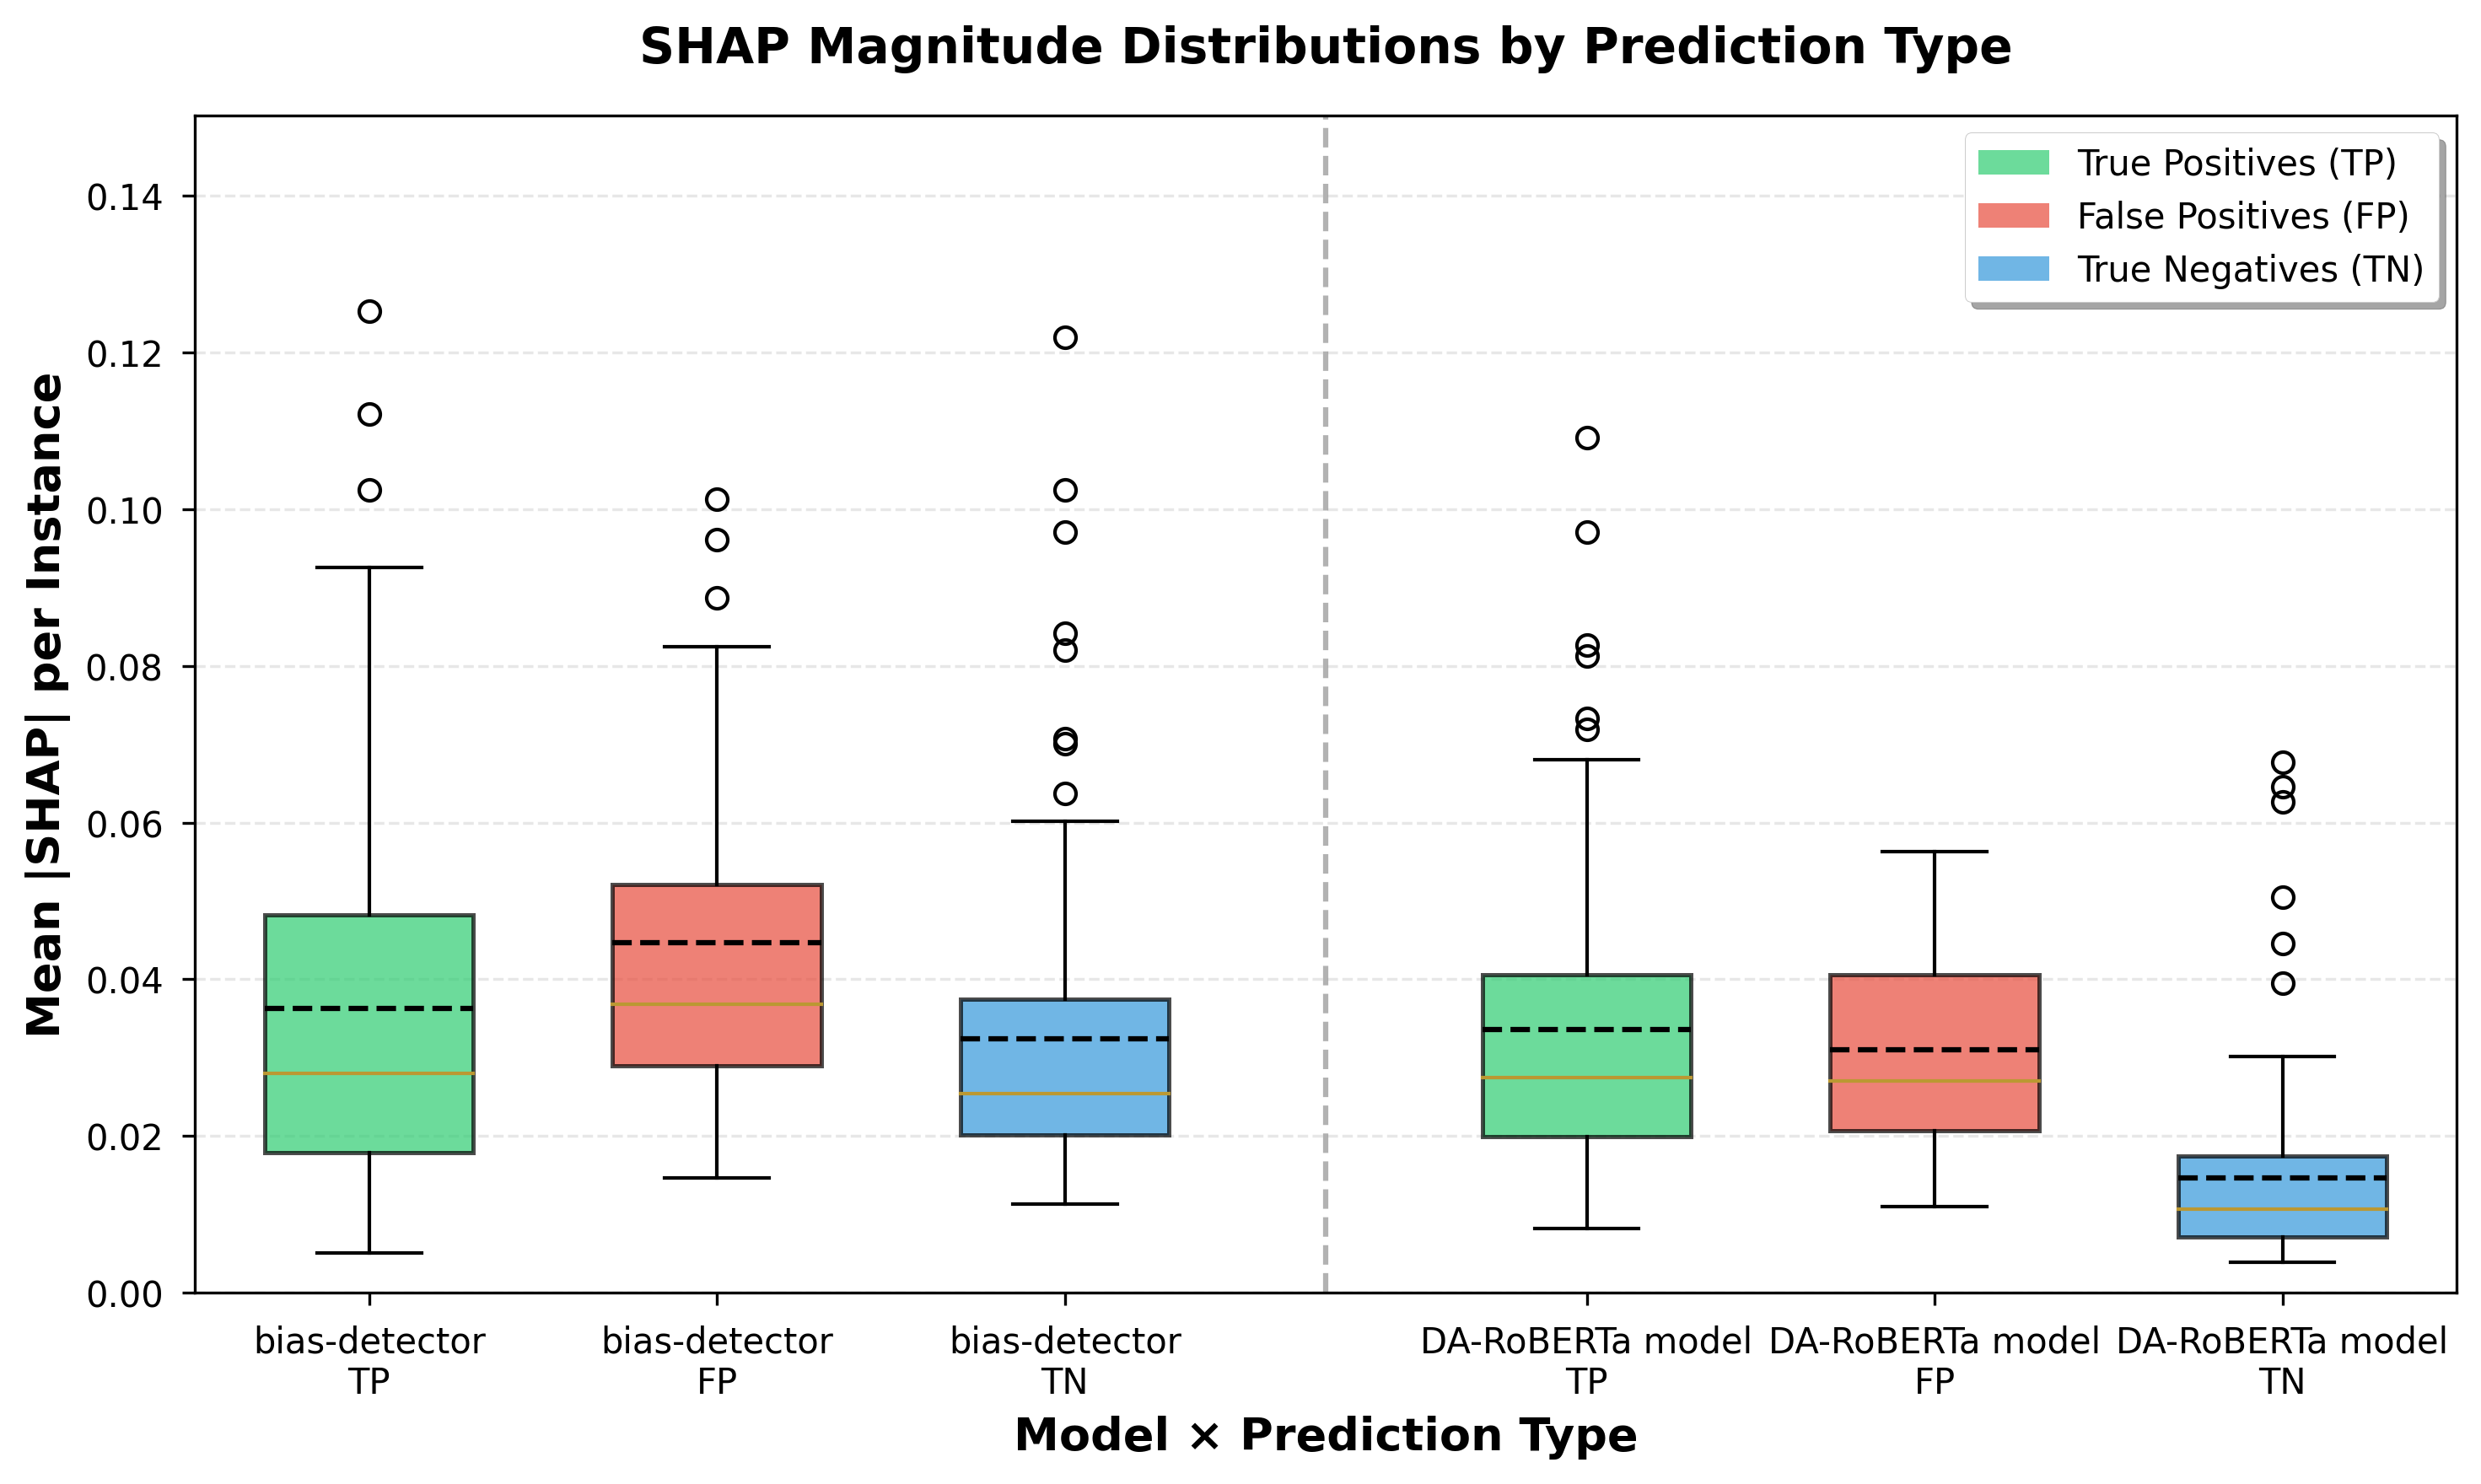

In [51]:
# Create single-panel version (just boxplot) - recommended for paper
fig2, ax = plt.subplots(1, 1, figsize=(10, 6))

bp2 = ax.boxplot(data_list, positions=positions, widths=0.6, patch_artist=True,
                 labels=x_labels,
                 showmeans=True, meanline=True, 
                 meanprops=dict(linestyle='--', linewidth=1.5, color='black'))

# Color the boxes
for i, patch in enumerate(bp2['boxes']):
    label = labels_list[i]
    if 'TP' in label:
        patch.set_facecolor(colors['TP'])
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)
    elif 'FP' in label:
        patch.set_facecolor(colors['FP'])
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)
    elif 'TN' in label:
        patch.set_facecolor(colors['TN'])
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)

ax.set_ylabel('Mean |SHAP| per Instance', fontsize=13, fontweight='bold')
ax.set_xlabel('Model × Prediction Type', fontsize=13, fontweight='bold')
ax.set_title('SHAP Magnitude Distributions by Prediction Type', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, max(df['mean_abs_shap']) * 1.2])

# Add vertical line to separate models
ax.axvline(x=mid_point, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)

# Add legend
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()

# Save single-panel version
output_path_single = os.path.join(output_dir, "figure1_shap_distributions_single.png")
plt.savefig(output_path_single, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Single-panel figure saved to: {output_path_single}")

plt.show()


## Summary Statistics for Paper


In [10]:
# Print detailed statistics for the paper
print("="*80)
print("STATISTICS FOR PAPER")
print("="*80)
print("\nMean |SHAP| by Model and Prediction Type:")
stats = df.groupby(['model', 'pred_type'])['mean_abs_shap'].agg(['mean', 'std', 'count']).round(4)
print(stats)

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)

# Original model statistics
orig_fp = df[(df['model'] == 'bias-detector') & (df['pred_type'] == 'FP')]['mean_abs_shap'].mean()
orig_tp = df[(df['model'] == 'bias-detector') & (df['pred_type'] == 'TP')]['mean_abs_shap'].mean()
print(f"\nOriginal Model (bias-detector):")
print(f"  FP mean |SHAP|: {orig_fp:.4f}")
print(f"  TP mean |SHAP|: {orig_tp:.4f}")
print(f"  Pattern: FP > TP (paradoxical) - FP is {((orig_fp/orig_tp - 1)*100):.1f}% higher")

# DA-RoBERTa statistics
daro_fp = df[(df['model'] == 'DA-RoBERTa') & (df['pred_type'] == 'FP')]['mean_abs_shap'].mean()
daro_tp = df[(df['model'] == 'DA-RoBERTa') & (df['pred_type'] == 'TP')]['mean_abs_shap'].mean()
print(f"\nDA-RoBERTa Model:")
print(f"  TP mean |SHAP|: {daro_tp:.4f}")
print(f"  FP mean |SHAP|: {daro_fp:.4f}")
print(f"  Pattern: TP > FP (intuitive) - TP is {((daro_tp/daro_fp - 1)*100):.1f}% higher")

print("\n" + "="*80)


STATISTICS FOR PAPER

Mean |SHAP| by Model and Prediction Type:
                           mean     std  count
model         pred_type                       
DA-RoBERTa    FP         0.0310  0.0150     12
              TN         0.0146  0.0125    100
              TP         0.0335  0.0193    100
bias-detector FP         0.0447  0.0220     37
              TN         0.0324  0.0199    100
              TP         0.0362  0.0255    100

KEY FINDINGS:

Original Model (bias-detector):
  FP mean |SHAP|: 0.0447
  TP mean |SHAP|: 0.0362
  Pattern: FP > TP (paradoxical) - FP is 23.4% higher

DA-RoBERTa Model:
  TP mean |SHAP|: 0.0335
  FP mean |SHAP|: 0.0310
  Pattern: TP > FP (intuitive) - TP is 8.3% higher



## Generate Figure 2: Global Top Bias Indicators

Side-by-side horizontal bar charts showing top 10 words by mean |SHAP| for each model.


In [11]:
# Load global word importance data
print("Loading global word importance data...")

# Original model
original_importance_path = os.path.join(output_dir, "global_word_importance.csv")
original_importance = pd.read_csv(original_importance_path)
print(f"✅ Loaded {len(original_importance)} words from original model")

# DA-RoBERTa model
daroberta_importance_path = os.path.join(output_dir, "global_word_importance_daroberta.csv")
daroberta_importance = pd.read_csv(daroberta_importance_path)
print(f"✅ Loaded {len(daroberta_importance)} words from DA-RoBERTa model")

# Get top 10 by mean_abs_shap for each model
# Sort in descending order so largest values appear at top of chart
top10_original = original_importance.nlargest(10, 'mean_abs_shap').sort_values('mean_abs_shap', ascending=False)
top10_daroberta = daroberta_importance.nlargest(10, 'mean_abs_shap').sort_values('mean_abs_shap', ascending=False)

print(f"\nTop 10 words for original model:")
for idx, row in top10_original.iterrows():
    print(f"  {row['word']}: {row['mean_abs_shap']:.4f}")

print(f"\nTop 10 words for DA-RoBERTa model:")
for idx, row in top10_daroberta.iterrows():
    print(f"  {row['word']}: {row['mean_abs_shap']:.4f}")


Loading global word importance data...
✅ Loaded 3146 words from original model
✅ Loaded 2850 words from DA-RoBERTa model

Top 10 words for original model:
  boasted: 0.7446
  bloated: 0.6797
  dubious: 0.5928
  antisemitic.: 0.5874
  skeptics: 0.5744
  relentlessly: 0.5633
  flagrantly,: 0.5510
  misleading: 0.5378
  toothless““: 0.5182
  frantically: 0.4504

Top 10 words for DA-RoBERTa model:
  heartlessness: 0.7673
  flippantly: 0.6344
  lashed: 0.4837
  antisemitic.: 0.4799
  dubious: 0.4656
  flippancy: 0.4525
  nasty: 0.4055
  blasted: 0.3837
  junkies: 0.3768
  sandbag: 0.3681



✅ Figure 2 saved to: outputs/figure2_top_bias_indicators.png


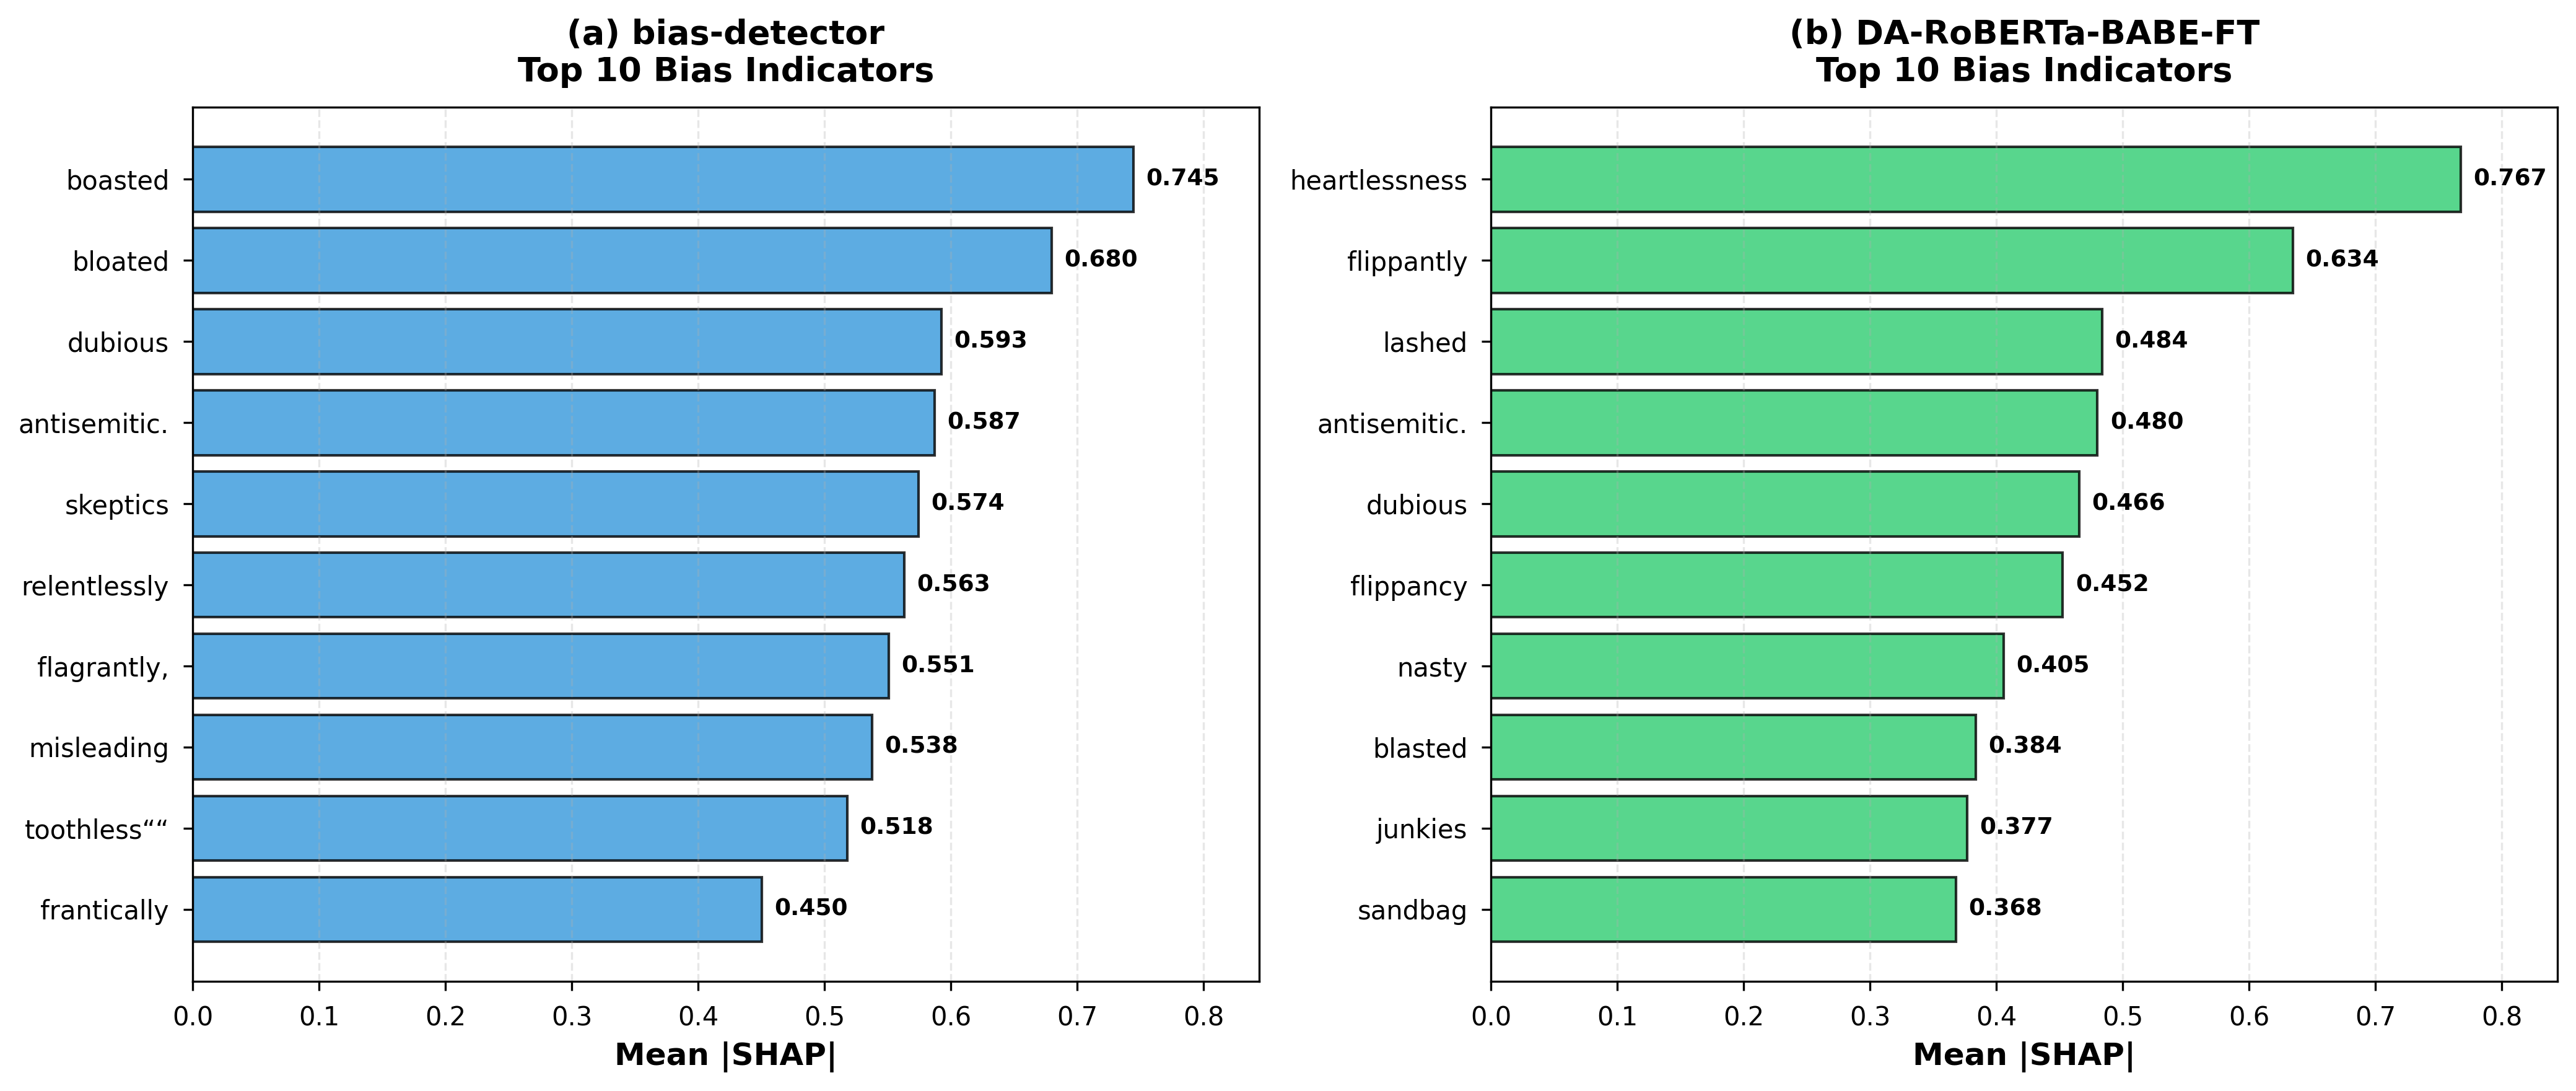

In [13]:
# Create Figure 2: Side-by-side horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define colors - use different color scheme for this figure
bar_color_original = '#3498db'  # Blue
bar_color_daroberta = '#2ecc71'  # Green

# Plot 1: Original Model (bias-detector)
ax1 = axes[0]
y_pos = np.arange(len(top10_original))
bars1 = ax1.barh(y_pos, top10_original['mean_abs_shap'].values, 
                 color=bar_color_original, alpha=0.8, edgecolor='black', linewidth=1)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(top10_original['word'].values, fontsize=10)
ax1.set_xlabel('Mean |SHAP|', fontsize=12, fontweight='bold')
ax1.set_title('(a) bias-detector\nTop 10 Bias Indicators', 
              fontsize=13, fontweight='bold', pad=10)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_xlim([0, max(top10_original['mean_abs_shap'].max(), top10_daroberta['mean_abs_shap'].max()) * 1.1])
ax1.invert_yaxis()  # Largest value at top

# Add value labels on bars
for i, (idx, row) in enumerate(top10_original.iterrows()):
    ax1.text(row['mean_abs_shap'] + 0.01, i, f"{row['mean_abs_shap']:.3f}",
            va='center', fontsize=9, fontweight='bold')

# Plot 2: DA-RoBERTa Model
ax2 = axes[1]
y_pos2 = np.arange(len(top10_daroberta))
bars2 = ax2.barh(y_pos2, top10_daroberta['mean_abs_shap'].values,
                 color=bar_color_daroberta, alpha=0.8, edgecolor='black', linewidth=1)

ax2.set_yticks(y_pos2)
ax2.set_yticklabels(top10_daroberta['word'].values, fontsize=10)
ax2.set_xlabel('Mean |SHAP|', fontsize=12, fontweight='bold')
ax2.set_title('(b) DA-RoBERTa-BABE-FT\nTop 10 Bias Indicators',
              fontsize=13, fontweight='bold', pad=10)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_xlim([0, max(top10_original['mean_abs_shap'].max(), top10_daroberta['mean_abs_shap'].max()) * 1.1])
ax2.invert_yaxis()  # Largest value at top

# Add value labels on bars
for i, (idx, row) in enumerate(top10_daroberta.iterrows()):
    ax2.text(row['mean_abs_shap'] + 0.01, i, f"{row['mean_abs_shap']:.3f}",
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()

# Save figure
output_path_fig2 = os.path.join(output_dir, "figure2_top_bias_indicators.png")
plt.savefig(output_path_fig2, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✅ Figure 2 saved to: {output_path_fig2}")

plt.show()


### Alternative: Combined single panel with both models (optional)


✅ Combined Figure 2 saved to: outputs/figure2_top_bias_indicators_combined.png


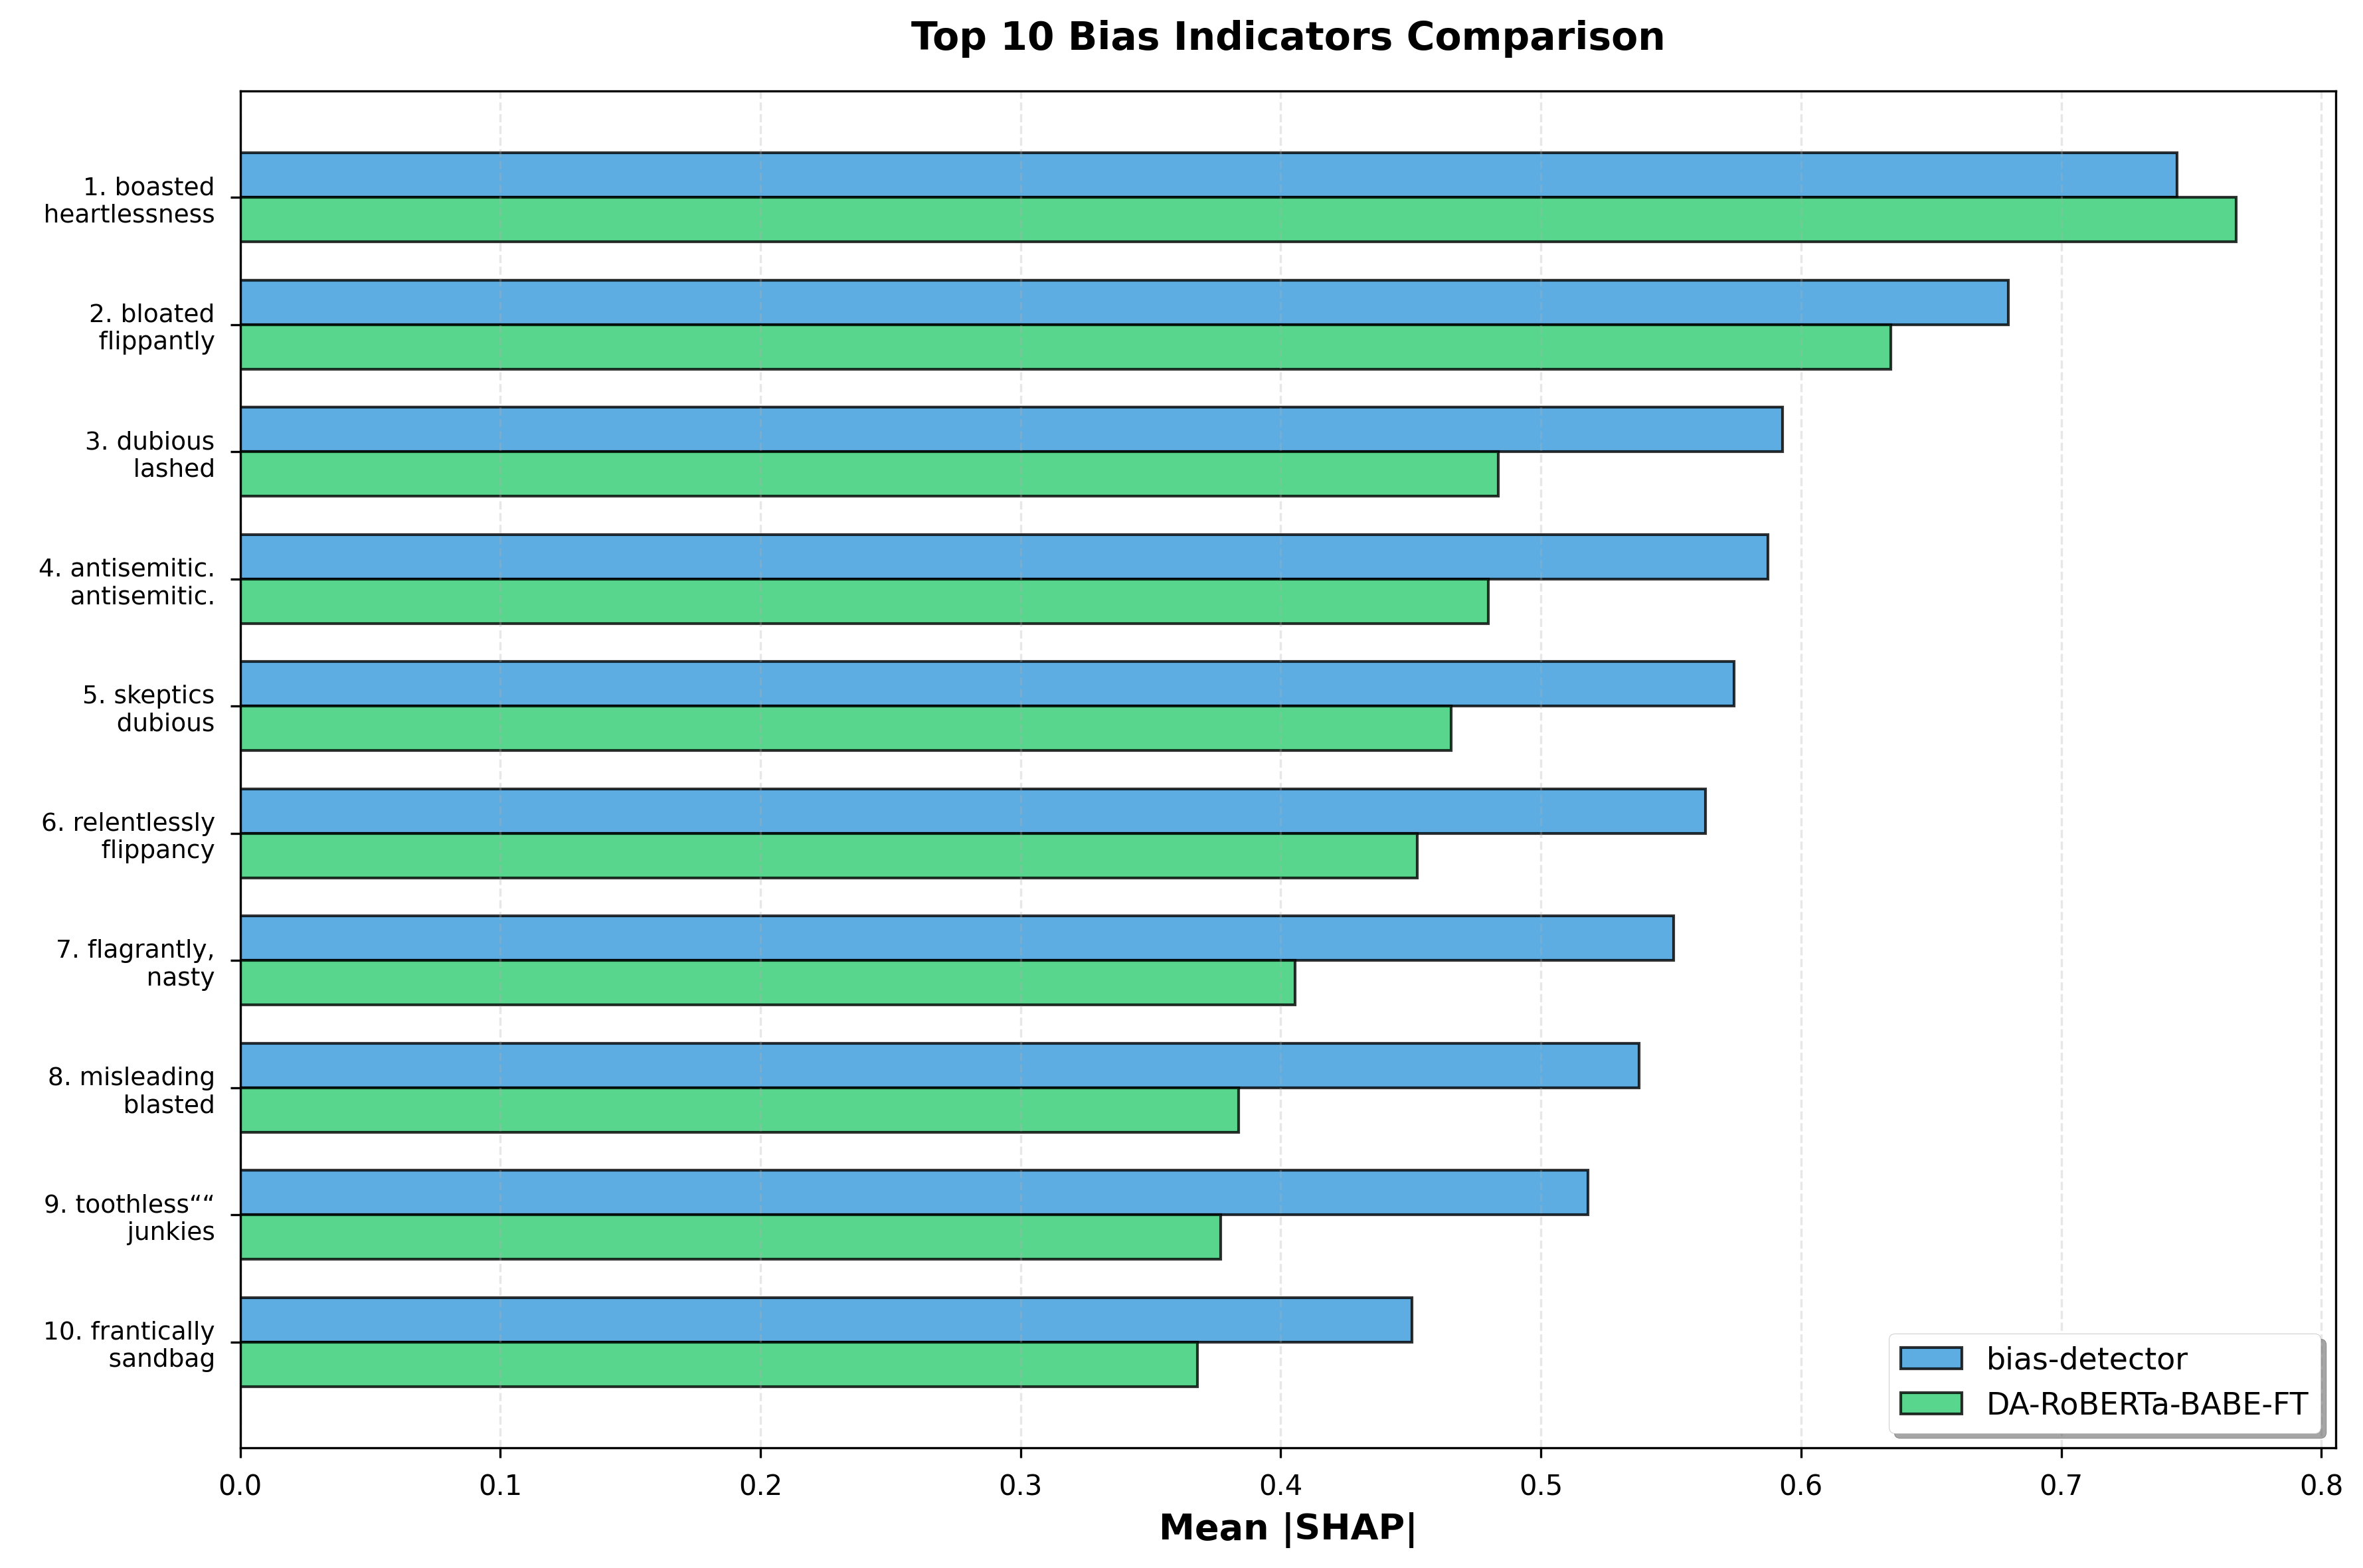

In [14]:
# Optional: Create a single combined figure with both models in one plot
# This can be useful for direct comparison in a single view

fig_combined, ax_combined = plt.subplots(1, 1, figsize=(12, 8))

# Prepare data - combine both models
max_top_n = 10
y_pos_combined = np.arange(max_top_n)
width = 0.35

# Get top N words (aligned indices) - reverse order for proper display (top at top)
top_orig_reversed = top10_original.sort_values('mean_abs_shap', ascending=False)
top_daro_reversed = top10_daroberta.sort_values('mean_abs_shap', ascending=False)

top_orig_values = top_orig_reversed['mean_abs_shap'].values[:max_top_n]
top_daro_values = top_daro_reversed['mean_abs_shap'].values[:max_top_n]
top_orig_words = top_orig_reversed['word'].values[:max_top_n]
top_daro_words = top_daro_reversed['word'].values[:max_top_n]

bars_orig = ax_combined.barh(y_pos_combined - width/2, top_orig_values,
                              width, label='bias-detector', color=bar_color_original, 
                              alpha=0.8, edgecolor='black', linewidth=1)
bars_daro = ax_combined.barh(y_pos_combined + width/2, top_daro_values,
                              width, label='DA-RoBERTa-BABE-FT', color=bar_color_daroberta,
                              alpha=0.8, edgecolor='black', linewidth=1)

# Create labels (combining both models' words)
labels_combined = []
for i in range(max_top_n):
    orig_word = top_orig_words[i] if i < len(top_orig_words) else ""
    daro_word = top_daro_words[i] if i < len(top_daro_words) else ""
    labels_combined.append(f"{i+1}. {orig_word}\n   {daro_word}")

ax_combined.set_yticks(y_pos_combined)
ax_combined.set_yticklabels(labels_combined, fontsize=9)
ax_combined.set_xlabel('Mean |SHAP|', fontsize=13, fontweight='bold')
ax_combined.set_title('Top 10 Bias Indicators Comparison', fontsize=14, fontweight='bold', pad=15)
ax_combined.grid(axis='x', alpha=0.3, linestyle='--')
ax_combined.legend(loc='lower right', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax_combined.invert_yaxis()  # Top rank at top

plt.tight_layout()

# Save combined figure
output_path_fig2_combined = os.path.join(output_dir, "figure2_top_bias_indicators_combined.png")
plt.savefig(output_path_fig2_combined, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Combined Figure 2 saved to: {output_path_fig2_combined}")

plt.show()


## Generate Figure 3: Word Category Composition of Top SHAP Features

Stacked bar charts showing proportions of word categories (emotional/evaluative, explicit bias terms, framing/reporting verbs, function/temporal words) for top SHAP features.


In [15]:
# Word categorization function
# Categories:
# 1. Emotional/Evaluative words
# 2. Explicit bias terms
# 3. Framing/Reporting verbs
# 4. Function/Temporal words

def categorize_word(word):
    """Categorize a word into one of the four categories."""
    word_lower = word.lower().strip('.,!?;:"()[]{}')
    
    # Explicit bias terms
    explicit_bias_terms = {
        'racist', 'antisemitic', 'xenophobic', 'sexist', 'bigoted', 'prejudice', 
        'discriminatory', 'stereotype', 'stereotyping', 'discrimination'
    }
    if any(term in word_lower for term in explicit_bias_terms):
        return 'Explicit Bias Terms'
    
    # Framing/Reporting verbs
    framing_verbs = {
        'claim', 'claims', 'claimed', 'claiming', 'allege', 'alleges', 'alleged', 'alleging',
        'report', 'reports', 'reported', 'reporting', 'state', 'states', 'stated', 'stating',
        'say', 'says', 'said', 'saying', 'suggest', 'suggests', 'suggested', 'suggesting',
        'assert', 'asserts', 'asserted', 'asserting', 'maintain', 'maintains', 'maintained',
        'insist', 'insists', 'insisted', 'insisting', 'argue', 'argues', 'argued', 'arguing',
        'call', 'calls', 'called', 'calling', 'describe', 'describes', 'described', 'describing',
        'characterize', 'characterizes', 'characterized', 'portray', 'portrays', 'portrayed'
    }
    if word_lower in framing_verbs:
        return 'Framing/Reporting Verbs'
    
    # Function/Temporal words
    function_words = {
        'the', 'a', 'an', 'and', 'or', 'but', 'if', 'of', 'to', 'in', 'on', 'at', 'for',
        'from', 'with', 'by', 'as', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
        'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'will', 'would',
        'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those',
        'it', 'its', 'they', 'them', 'their', 'there', 'then', 'than', 'more', 'most',
        'some', 'any', 'all', 'each', 'every', 'other', 'another', 'much', 'many', 'very'
    }
    temporal_words = {
        'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday',
        'today', 'yesterday', 'tomorrow', 'now', 'then', 'when', 'before', 'after',
        'during', 'while', 'since', 'until', 'ago', 'recently', 'previously', 'earlier',
        'later', 'next', 'last', 'year', 'years', 'month', 'months', 'week', 'weeks',
        'day', 'days', 'hour', 'hours', 'time', 'times'
    }
    if word_lower in function_words or word_lower in temporal_words:
        return 'Function/Temporal Words'
    
    # Emotional/Evaluative words (default category for loaded/emotive language)
    emotional_evaluative_terms = {
        'boasted', 'bloated', 'dubious', 'relentlessly', 'flagrantly', 'misleading',
        'frantically', 'sided', 'mess', 'quixotic', 'lashed', 'denigrate', 'bizarre',
        'uglier', 'blown', 'nasty', 'ranted', 'heartlessness', 'flippantly', 'flippancy',
        'blasted', 'junkies', 'sandbag', 'guzzling', 'gruesome', 'predominantly',
        'relentless', 'fierce', 'heated', 'intense', 'extreme', 'drastic', 'radical',
        'mockery', 'ridicule', 'scorn', 'contempt', 'disgust', 'anger', 'hate', 'despise',
        'amazing', 'terrible', 'awful', 'horrible', 'wonderful', 'fantastic', 'incredible'
    }
    
    # Also check for emotional patterns
    if any(term in word_lower for term in emotional_evaluative_terms):
        return 'Emotional/Evaluative'
    
    # Check for evaluative suffixes/patterns
    evaluative_suffixes = ['less', 'ful', 'ous', 'ing']  # Common but context-dependent
    # Words ending in evaluative patterns
    if word_lower.endswith('less') or word_lower.endswith('ful'):
        if len(word_lower) > 4:  # Avoid very short words
            return 'Emotional/Evaluative'
    
    # Default: If it doesn't fit other categories, likely emotional/evaluative in bias context
    # This is a heuristic - in practice, manual review would be ideal
    return 'Emotional/Evaluative'

# Test categorization on a few examples
test_words = ['boasted', 'racist', 'claimed', 'the', 'monday', 'dubious', 'lashed', 'antisemitic']
print("Testing word categorization:")
for word in test_words:
    cat = categorize_word(word)
    print(f"  {word:15} → {cat}")


Testing word categorization:
  boasted         → Emotional/Evaluative
  racist          → Explicit Bias Terms
  claimed         → Framing/Reporting Verbs
  the             → Function/Temporal Words
  monday          → Function/Temporal Words
  dubious         → Emotional/Evaluative
  lashed          → Emotional/Evaluative
  antisemitic     → Explicit Bias Terms


In [25]:
# Load word importance data and categorize top words
print("Categorizing top words for both models...")

# Get top N words (e.g., top 50) for categorization
top_n = 100

# Original model
top_words_orig = original_importance.nlargest(top_n, 'mean_abs_shap')
top_words_orig['category'] = top_words_orig['word'].apply(categorize_word)

# DA-RoBERTa model
top_words_daro = daroberta_importance.nlargest(top_n, 'mean_abs_shap')
top_words_daro['category'] = top_words_daro['word'].apply(categorize_word)

print(f"✅ Categorized top {top_n} words for both models")

# Calculate category proportions
def calculate_category_proportions(df):
    """Calculate proportion of each category in top words."""
    category_counts = df['category'].value_counts()
    category_props = category_counts / len(df) * 100  # Percentage
    return category_props.to_dict()

orig_props = calculate_category_proportions(top_words_orig)
daro_props = calculate_category_proportions(top_words_daro)

print(f"\nOriginal Model (bias-detector) category proportions:")
for cat, prop in sorted(orig_props.items()):
    print(f"  {cat}: {prop:.1f}%")

print(f"\nDA-RoBERTa Model category proportions:")
for cat, prop in sorted(daro_props.items()):
    print(f"  {cat}: {prop:.1f}%")


Categorizing top words for both models...
✅ Categorized top 100 words for both models

Original Model (bias-detector) category proportions:
  Emotional/Evaluative: 93.0%
  Explicit Bias Terms: 3.0%
  Framing/Reporting Verbs: 2.0%
  Function/Temporal Words: 2.0%

DA-RoBERTa Model category proportions:
  Emotional/Evaluative: 92.0%
  Explicit Bias Terms: 2.0%
  Framing/Reporting Verbs: 6.0%



✅ Figure 3 saved to: outputs/figure3_word_category_composition.png


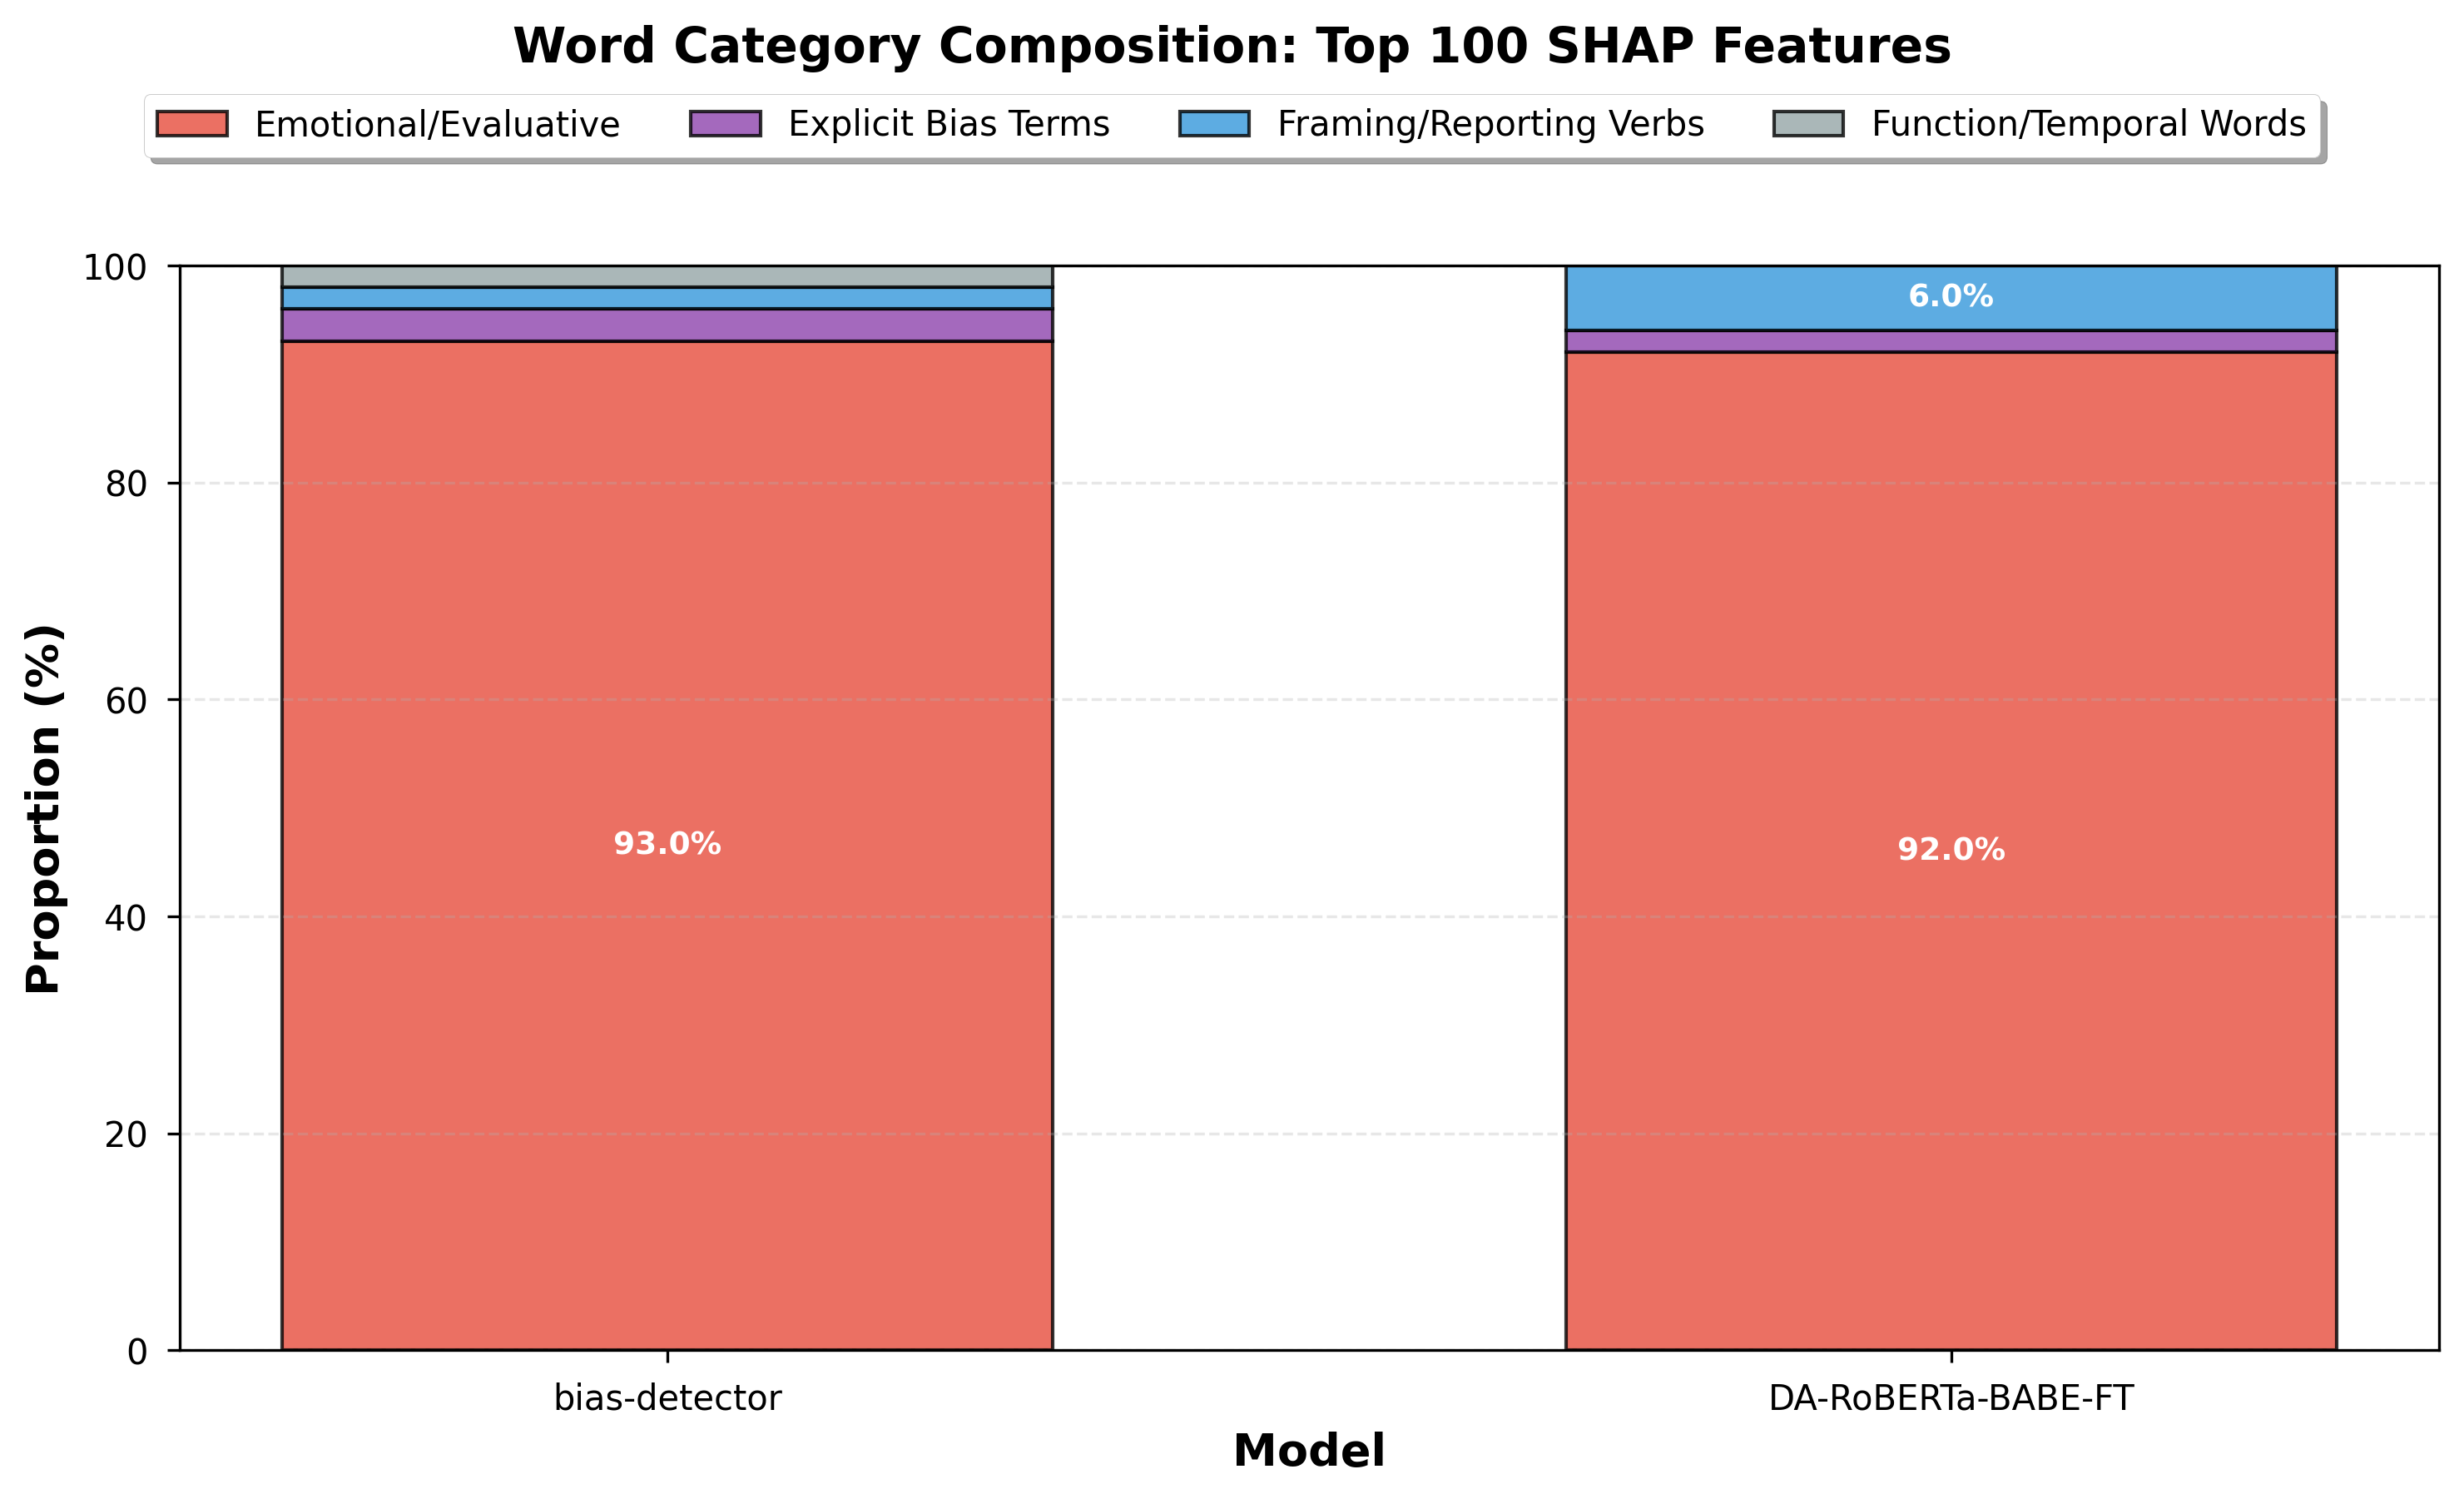

In [52]:
# Create Figure 3: Stacked Bar Chart
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Define category order and colors
categories = ['Emotional/Evaluative', 'Explicit Bias Terms', 
              'Framing/Reporting Verbs', 'Function/Temporal Words']
colors = {
    'Emotional/Evaluative': '#e74c3c',  # Red
    'Explicit Bias Terms': '#8e44ad',    # Purple
    'Framing/Reporting Verbs': '#3498db', # Blue
    'Function/Temporal Words': '#95a5a6'  # Gray
}

# Prepare data for stacking
models = ['bias-detector', 'DA-RoBERTa-BABE-FT']
bottom_orig = 0
bottom_daro = 0

x_pos = np.arange(len(models))
width = 0.6

# Create bars for each category
for i, category in enumerate(categories):
    orig_val = orig_props.get(category, 0)
    daro_val = daro_props.get(category, 0)
    
    # Original model
    ax.bar(x_pos[0], orig_val, width, bottom=bottom_orig, 
           label=category, 
           color=colors[category], alpha=0.8, edgecolor='black', linewidth=1)
    
    # DA-RoBERTa model
    ax.bar(x_pos[1], daro_val, width, bottom=bottom_daro,
           color=colors[category], alpha=0.8, edgecolor='black', linewidth=1)
    
    bottom_orig += orig_val
    bottom_daro += daro_val
    
    # Add percentage labels in the middle of each segment
    if orig_val > 3:  # Only label if segment is large enough
        ax.text(x_pos[0], bottom_orig - orig_val/2, f'{orig_val:.1f}%',
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if daro_val > 3:
        ax.text(x_pos[1], bottom_daro - daro_val/2, f'{daro_val:.1f}%',
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_ylabel('Proportion (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
#ax.set_title(f'Word Category Composition of Top {top_n} SHAP Features', 
             #fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3, linestyle='--')
#ax.legend(loc='upper right', fontsize=10, frameon=True, fancybox=True, shadow=True)
# Add overall title and legend
fig.suptitle(f'Word Category Composition: Top {top_n} SHAP Features', 
             fontsize=14, fontweight='bold', y=0.995)
fig.legend(handles=[plt.Rectangle((0,0),1,1, facecolor=colors[cat], alpha=0.8, 
                                  edgecolor='black', linewidth=1) 
                    for cat in categories],
          labels=categories,
          loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=4, 
          frameon=True, fancybox=True, shadow=True, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# Save figure
output_path_fig3 = os.path.join(output_dir, "figure3_word_category_composition.png")
plt.savefig(output_path_fig3, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✅ Figure 3 saved to: {output_path_fig3}")

plt.show()


### Optional: Breakdown by TP vs. FP (if data available)


In [28]:
# Optional: Breakdown by TP vs. FP
# This requires extracting word attributions from SHAP samples by prediction type

def extract_top_words_by_pred_type(samples, pred_type, top_n=100):
    """Extract top words by mean |SHAP| for a specific prediction type."""
    word_dict = {}
    
    for sample in samples:
        # Check if this sample matches the prediction type
        gold = sample.get('gold', -1)
        pred = sample.get('pred', -1)
        
        sample_pred_type = determine_pred_type(gold, pred)
        if sample_pred_type != pred_type:
            continue
            
        # Extract word attributions
        word_attribs = sample.get('word_attribs', [])
        for word_attr in word_attribs:
            word = word_attr['word'].lower().strip('.,!?;:"()[]{}')
            abs_shap = abs(word_attr.get('shap', 0))
            
            if word not in word_dict:
                word_dict[word] = {'total_shap': 0, 'count': 0}
            word_dict[word]['total_shap'] += abs_shap
            word_dict[word]['count'] += 1
    
    # Calculate mean |SHAP| for each word
    word_df = pd.DataFrame([
        {'word': word, 'mean_abs_shap': data['total_shap'] / data['count'], 'count': data['count']}
        for word, data in word_dict.items()
    ])
    
    # Get top N
    top_words = word_df.nlargest(top_n, 'mean_abs_shap')
    top_words['category'] = top_words['word'].apply(categorize_word)
    
    return top_words

print("Extracting words by prediction type...")

# Extract for original model
orig_tp_words = extract_top_words_by_pred_type(original_samples, 'TP', top_n=100)
orig_fp_words = extract_top_words_by_pred_type(original_samples, 'FP', top_n=100)

# Extract for DA-RoBERTa model
daro_tp_words = extract_top_words_by_pred_type(daroberta_samples, 'TP', top_n=100)
daro_fp_words = extract_top_words_by_pred_type(daroberta_samples, 'FP', top_n=100)

print(f"✅ Extracted words for TP/FP breakdown")
print(f"\nOriginal Model - TP: {len(orig_tp_words)} words, FP: {len(orig_fp_words)} words")
print(f"DA-RoBERTa Model - TP: {len(daro_tp_words)} words, FP: {len(daro_fp_words)} words")


Extracting words by prediction type...
✅ Extracted words for TP/FP breakdown

Original Model - TP: 100 words, FP: 100 words
DA-RoBERTa Model - TP: 100 words, FP: 100 words



✅ Figure 3b (TP/FP breakdown) saved to: outputs/figure3_tp_fp_breakdown.png


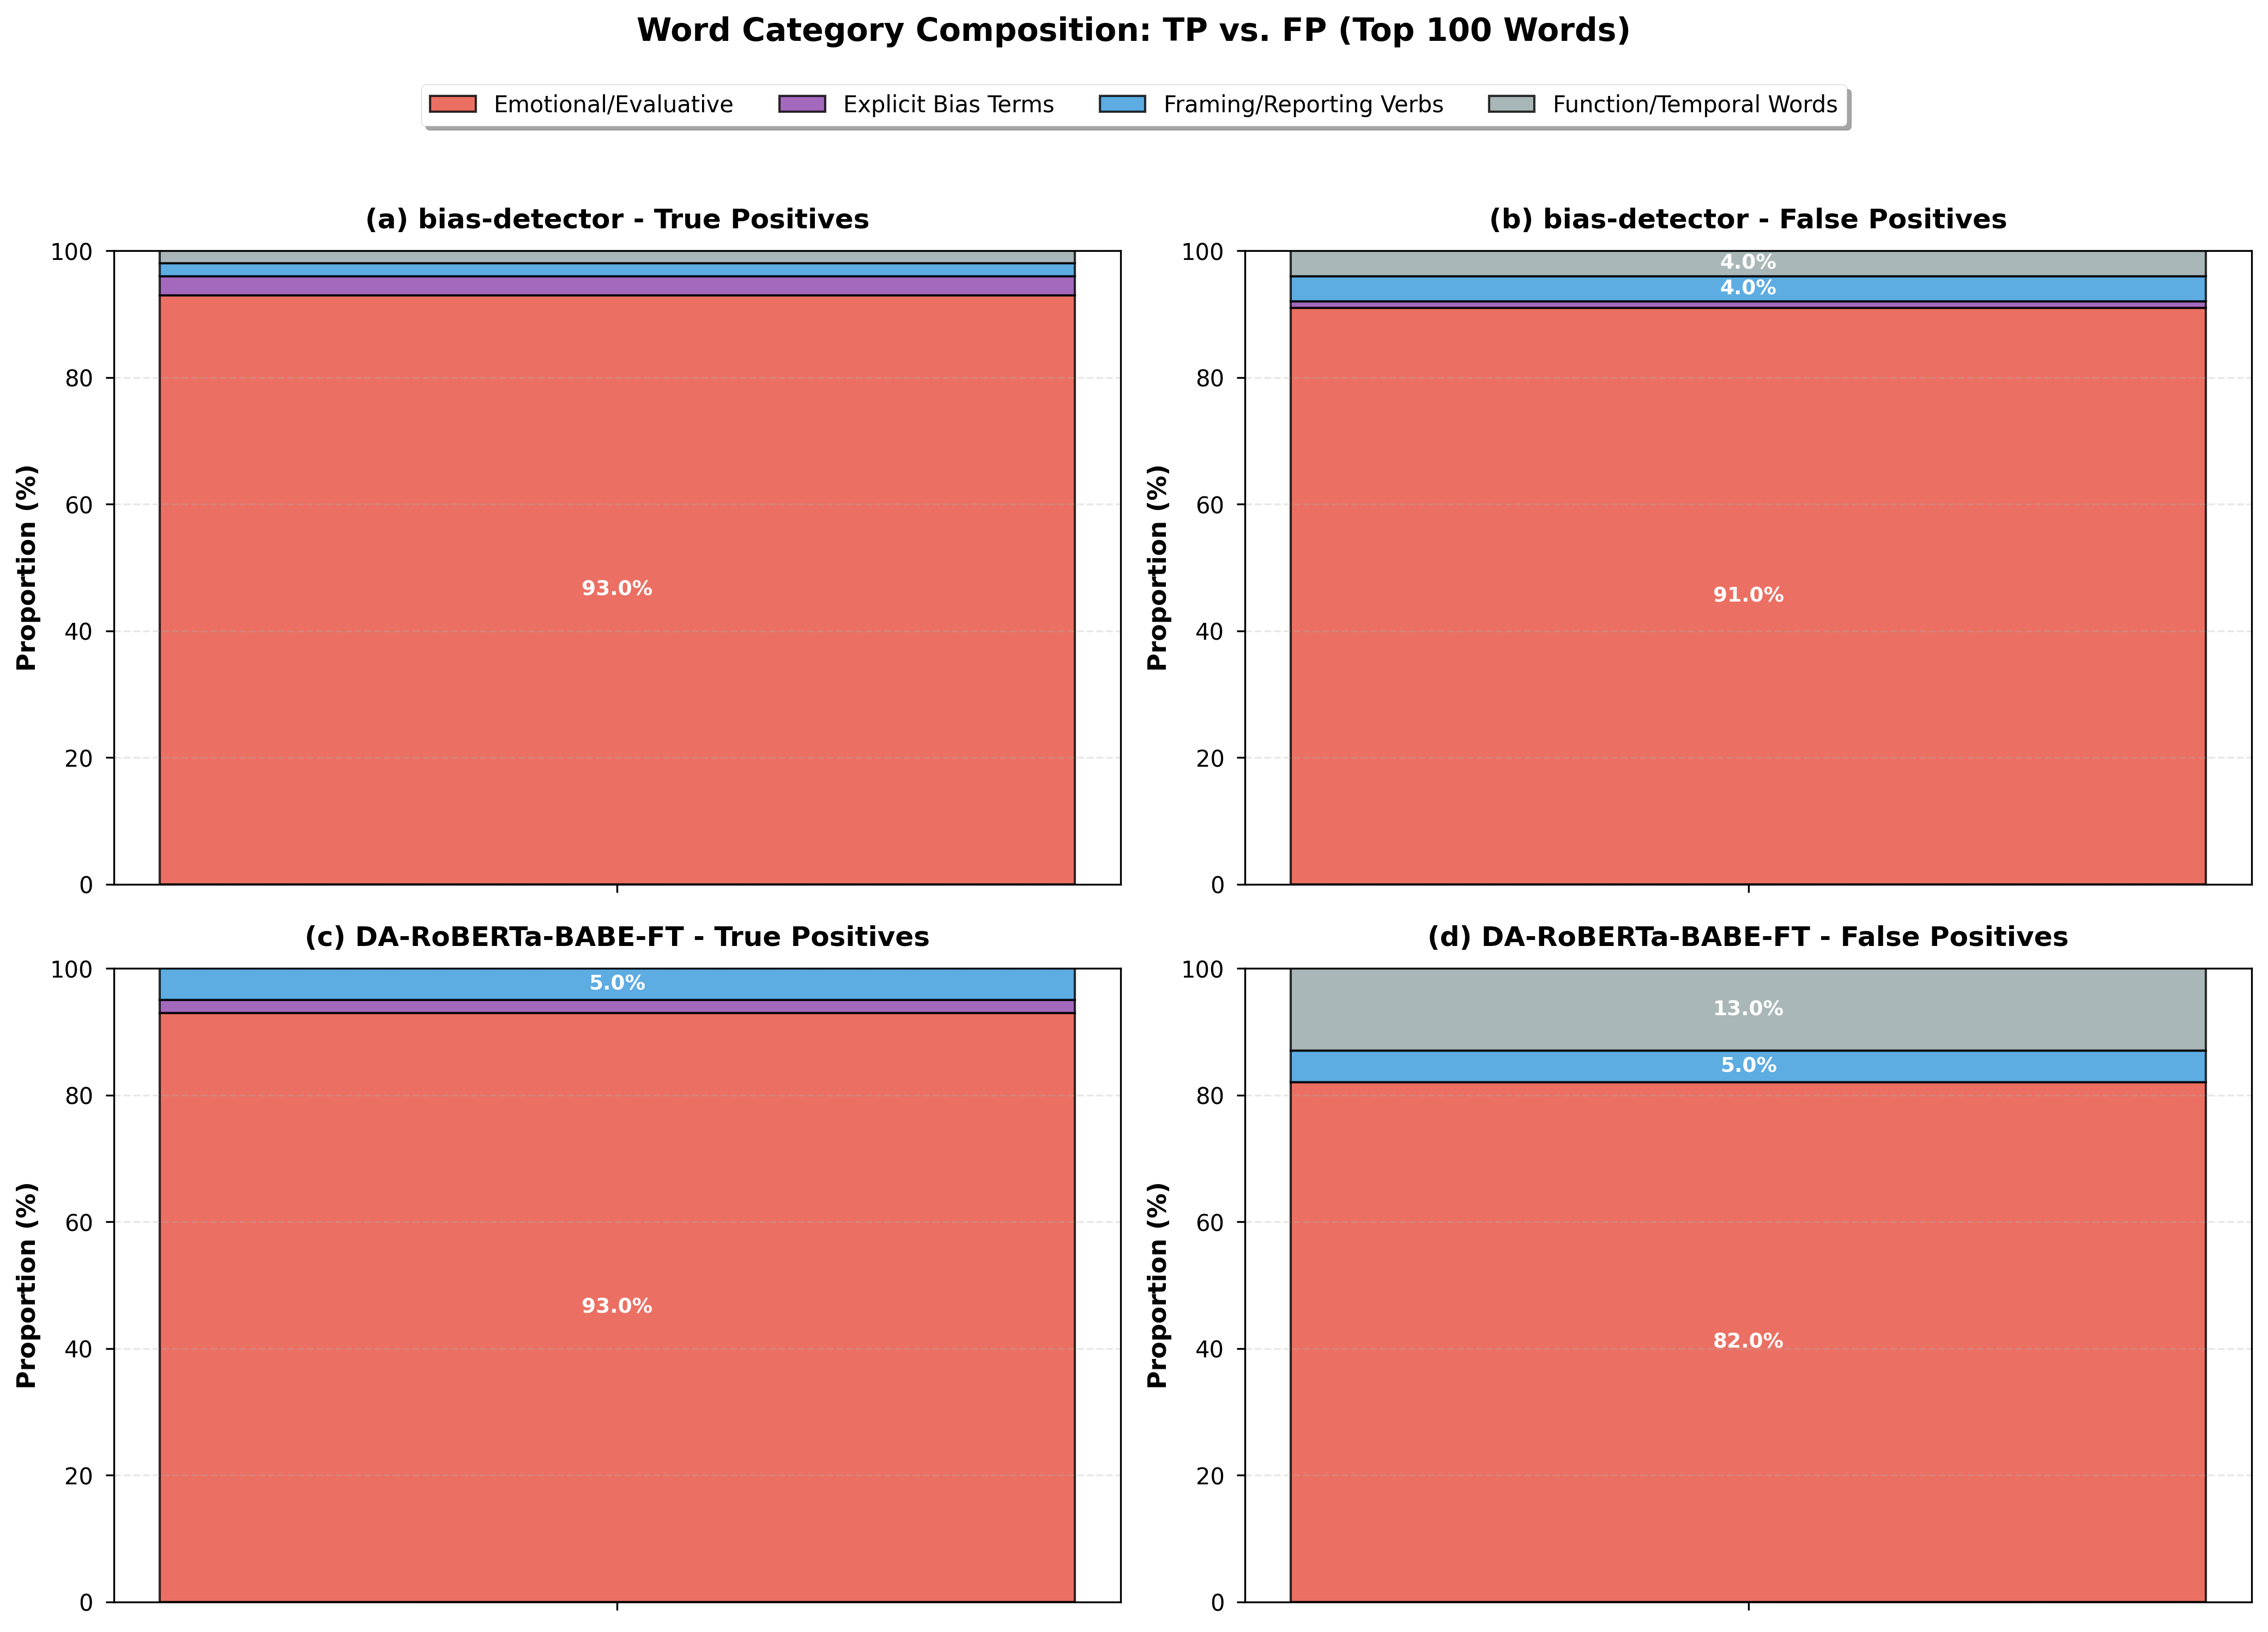

In [53]:
# Create Figure 3b: Breakdown by TP vs. FP (2x2 subplot grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Calculate proportions for each
orig_tp_props = calculate_category_proportions(orig_tp_words)
orig_fp_props = calculate_category_proportions(orig_fp_words)
daro_tp_props = calculate_category_proportions(daro_tp_words)
daro_fp_props = calculate_category_proportions(daro_fp_words)

# Plot 1: Original Model - TP
ax1 = axes[0, 0]
bottom = 0
for category in categories:
    val = orig_tp_props.get(category, 0)
    if val > 0:
        ax1.bar(0, val, width=0.6, bottom=bottom, 
               color=colors[category], alpha=0.8, 
               edgecolor='black', linewidth=1)
        if val > 3:
            ax1.text(0, bottom + val/2, f'{val:.1f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        bottom += val
ax1.set_ylabel('Proportion (%)', fontsize=11, fontweight='bold')
ax1.set_title('(a) bias-detector - True Positives', fontsize=12, fontweight='bold', pad=10)
ax1.set_xticks([0])
ax1.set_xticklabels([''])
ax1.set_ylim([0, 100])
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Original Model - FP
ax2 = axes[0, 1]
bottom = 0
for category in categories:
    val = orig_fp_props.get(category, 0)
    if val > 0:
        ax2.bar(0, val, width=0.6, bottom=bottom, 
               color=colors[category], alpha=0.8, 
               edgecolor='black', linewidth=1)
        if val > 3:
            ax2.text(0, bottom + val/2, f'{val:.1f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        bottom += val
ax2.set_ylabel('Proportion (%)', fontsize=11, fontweight='bold')
ax2.set_title('(b) bias-detector - False Positives', fontsize=12, fontweight='bold', pad=10)
ax2.set_xticks([0])
ax2.set_xticklabels([''])
ax2.set_ylim([0, 100])
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: DA-RoBERTa - TP
ax3 = axes[1, 0]
bottom = 0
for category in categories:
    val = daro_tp_props.get(category, 0)
    if val > 0:
        ax3.bar(0, val, width=0.6, bottom=bottom, 
               color=colors[category], alpha=0.8, 
               edgecolor='black', linewidth=1)
        if val > 3:
            ax3.text(0, bottom + val/2, f'{val:.1f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        bottom += val
ax3.set_ylabel('Proportion (%)', fontsize=11, fontweight='bold')
ax3.set_title('(c) DA-RoBERTa-BABE-FT - True Positives', fontsize=12, fontweight='bold', pad=10)
ax3.set_xticks([0])
ax3.set_xticklabels([''])
ax3.set_ylim([0, 100])
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 4: DA-RoBERTa - FP
ax4 = axes[1, 1]
bottom = 0
for category in categories:
    val = daro_fp_props.get(category, 0)
    if val > 0:
        ax4.bar(0, val, width=0.6, bottom=bottom, 
               color=colors[category], alpha=0.8, 
               edgecolor='black', linewidth=1)
        if val > 3:
            ax4.text(0, bottom + val/2, f'{val:.1f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        bottom += val
ax4.set_ylabel('Proportion (%)', fontsize=11, fontweight='bold')
ax4.set_title('(d) DA-RoBERTa-BABE-FT - False Positives', fontsize=12, fontweight='bold', pad=10)
ax4.set_xticks([0])
ax4.set_xticklabels([''])
ax4.set_ylim([0, 100])
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Add overall title and legend
fig.suptitle(f'Word Category Composition: TP vs. FP (Top 100 Words)', 
             fontsize=14, fontweight='bold', y=0.995)
fig.legend(handles=[plt.Rectangle((0,0),1,1, facecolor=colors[cat], alpha=0.8, 
                                  edgecolor='black', linewidth=1) 
                    for cat in categories],
          labels=categories,
          loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=4, 
          frameon=True, fancybox=True, shadow=True, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# Save figure
output_path_fig3b = os.path.join(output_dir, "figure3_tp_fp_breakdown.png")
plt.savefig(output_path_fig3b, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✅ Figure 3b (TP/FP breakdown) saved to: {output_path_fig3b}")

plt.show()


In [20]:
# Print summary statistics
print("="*80)
print("FIGURE 3 SUMMARY STATISTICS")
print("="*80)

print("\nGlobal Top 50 Words:")
print("\nOriginal Model (bias-detector):")
for cat, prop in sorted(orig_props.items()):
    print(f"  {cat}: {prop:.1f}%")

print("\nDA-RoBERTa Model:")
for cat, prop in sorted(daro_props.items()):
    print(f"  {cat}: {prop:.1f}%")

print("\n\nTrue Positives (Top 30):")
print("\nOriginal Model - TP:")
for cat, prop in sorted(orig_tp_props.items()):
    print(f"  {cat}: {prop:.1f}%")

print("\nDA-RoBERTa - TP:")
for cat, prop in sorted(daro_tp_props.items()):
    print(f"  {cat}: {prop:.1f}%")

print("\n\nFalse Positives (Top 30):")
print("\nOriginal Model - FP:")
for cat, prop in sorted(orig_fp_props.items()):
    print(f"  {cat}: {prop:.1f}%")

print("\nDA-RoBERTa - FP:")
for cat, prop in sorted(daro_fp_props.items()):
    print(f"  {cat}: {prop:.1f}%")

print("\n" + "="*80)


FIGURE 3 SUMMARY STATISTICS

Global Top 50 Words:

Original Model (bias-detector):
  Emotional/Evaluative: 92.0%
  Explicit Bias Terms: 4.0%
  Framing/Reporting Verbs: 2.0%
  Function/Temporal Words: 2.0%

DA-RoBERTa Model:
  Emotional/Evaluative: 92.0%
  Explicit Bias Terms: 4.0%
  Framing/Reporting Verbs: 4.0%


True Positives (Top 30):

Original Model - TP:
  Emotional/Evaluative: 96.7%
  Explicit Bias Terms: 3.3%

DA-RoBERTa - TP:
  Emotional/Evaluative: 90.0%
  Explicit Bias Terms: 6.7%
  Framing/Reporting Verbs: 3.3%


False Positives (Top 30):

Original Model - FP:
  Emotional/Evaluative: 93.3%
  Framing/Reporting Verbs: 3.3%
  Function/Temporal Words: 3.3%

DA-RoBERTa - FP:
  Emotional/Evaluative: 86.7%
  Framing/Reporting Verbs: 10.0%
  Function/Temporal Words: 3.3%

